In [1]:
import os
import matplotlib.pyplot as plt

# Move from notebooks/ → project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Graphs folder
GRAPHS_DIR = os.path.join(PROJECT_ROOT, "Graphs")
os.makedirs(GRAPHS_DIR, exist_ok=True)

print("Graphs will be saved to:", GRAPHS_DIR)


Graphs will be saved to: c:\Users\usdas\Desktop\DEVANSHI ALLLLL\PROJECTS\customer-churn-analysis\Graphs


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [3]:
df = pd.read_csv("C:\\Users\\usdas\\Desktop\\DEVANSHI ALLLLL\\PROJECTS\\customer-churn-analysis\\data\\raw\\churn_data.csv")


In [4]:
# View first 5 rows
df.head()

# Dataset shape
df.shape

# Data types & missing values
df.info()

# Statistical summary
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
def save_all_figures(prefix):
    for i in plt.get_fignums():
        fig = plt.figure(i)
        fig.savefig(
            os.path.join(GRAPHS_DIR, f"{prefix}_figure_{i}.png"),
            dpi=300,
            bbox_inches="tight"
        )

# CHANGE prefix per notebook
save_all_figures("EDA")     # for 01_EDA.ipynb
# save_all_figures("CLEAN") # for 02_Data_Cleaning_Feature_Engineering.ipynb
# save_all_figures("MODEL") # for 03_Model_Building.ipynb


In [6]:
# Count churn values
df['Churn'].value_counts()

# Percentage of churn
df['Churn'].value_counts(normalize=True)


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

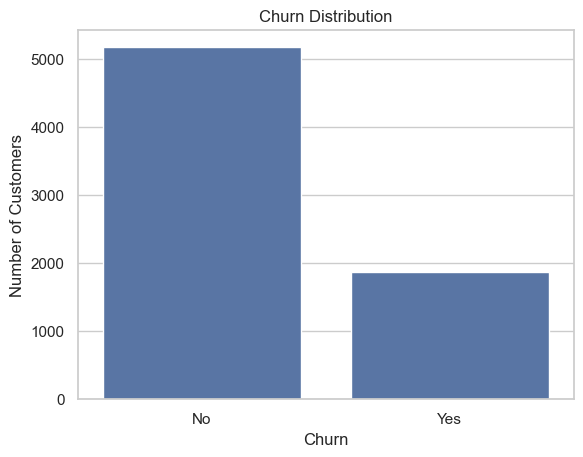

<Figure size 640x480 with 0 Axes>

In [ ]:
def save_plot(name):
    fig = plt.gcf()   # get current figure explicitly
    fig.savefig(
        os.path.join(GRAPHS_DIR, f"{name}.png"),
        dpi=300,
        bbox_inches="tight"
    )


# Plot churn distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

save_plot("churn_distribution")
plt.show()


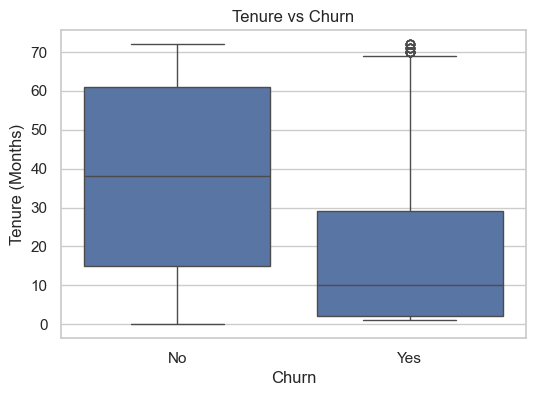

<Figure size 640x480 with 0 Axes>

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

save_plot("tenure_vs_churn")
plt.show()

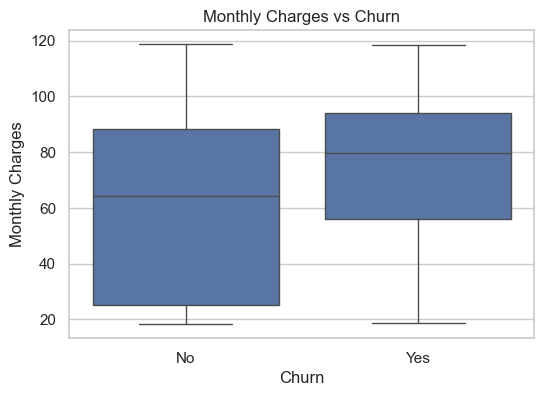

<Figure size 640x480 with 0 Axes>

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()
save_plot("monthly_charges_vs_churn")
plt.show()

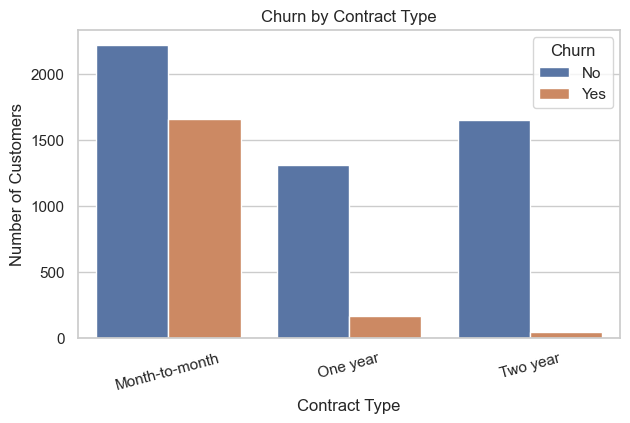

<Figure size 640x480 with 0 Axes>

In [10]:
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()
save_plot("churn_by_contract_type")
plt.show()

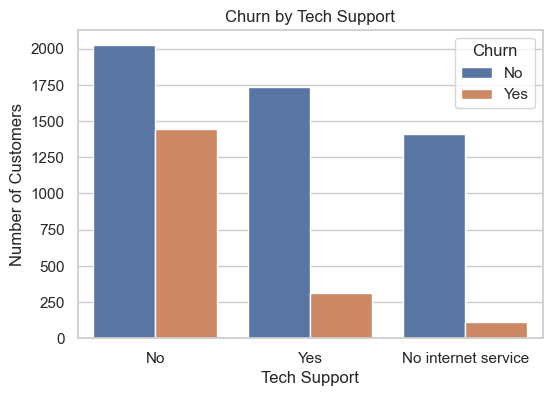

<Figure size 640x480 with 0 Axes>

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.title("Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")
plt.show()
save_plot("churn_by_tech_support")
plt.show()

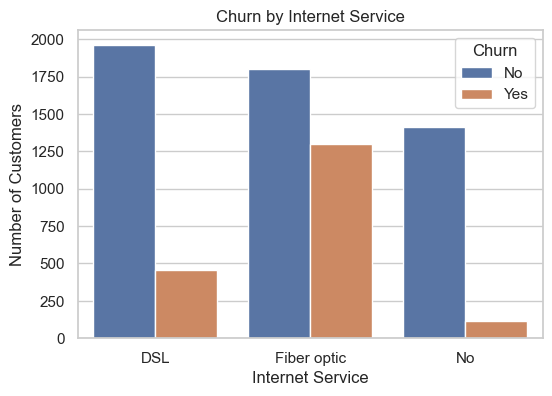

<Figure size 640x480 with 0 Axes>

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()
save_plot("churn_by_internet_service")
plt.show()

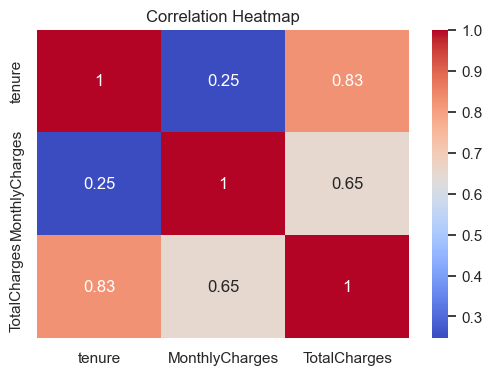

<Figure size 640x480 with 0 Axes>

In [13]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Select numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Correlation matrix
corr_matrix = df[num_cols].corr()

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
save_plot("correlation_heatmap")
plt.show()

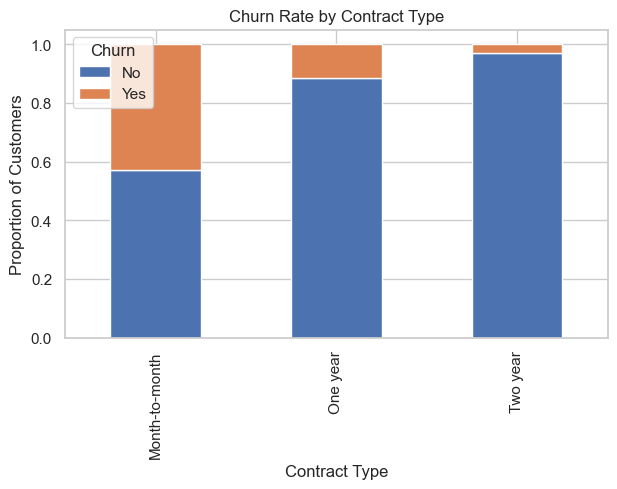

<Figure size 640x480 with 0 Axes>

In [14]:
churn_contract = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()

churn_contract.plot(kind='bar', stacked=True, figsize=(7,4))
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Proportion of Customers")
plt.legend(title="Churn")
plt.show()
save_plot("churn_rate_by_contract")
plt.show()


In [15]:
print("KEY EDA INSIGHTS")
print("----------------")
print("• Customers with low tenure churn more")
print("• Month-to-month contracts have highest churn")
print("• Higher monthly charges increase churn")
print("• Customers without tech support churn more")


KEY EDA INSIGHTS
----------------
• Customers with low tenure churn more
• Month-to-month contracts have highest churn
• Higher monthly charges increase churn
• Customers without tech support churn more


In [ ]:
def save_plot(name):
    fig = plt.gcf()   # get current figure explicitly
    fig.savefig(
        os.path.join(GRAPHS_DIR, f"{name}.png"),
        dpi=300,
        bbox_inches="tight"
    )
